# 01 - Data Loading and Exploratory Data Analysis

In this notebook, I start the project from the raw Steam interaction data.  
The goal of this step is to understand the structure of the dataset before moving into clustering, modeling, and dashboard development.

## 1. Import libraries and project paths

I first import the basic libraries used in the course and connect the notebook to the project folders.

In [32]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR
from src.data_processing import load_steam_data, clean_steam_data, create_user_features

## 2. Load the raw dataset

The Steam dataset is stored as a raw CSV file under `data/raw`.  
The file does not include column names, so the loading function assigns the expected column names.

In [33]:
raw_path = RAW_DATA_DIR / "steam-200k.csv"

df_raw = load_steam_data(raw_path)
df_raw.head()

,user_id,game,action,hours,unused
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0


## 3. Basic dataset overview

Before making any changes, I check the size of the raw dataset and the basic column information.

In [34]:
df_raw.shape

(200000, 5)

In [35]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  200000 non-null  int64  
 1   game     200000 non-null  object 
 2   action   200000 non-null  object 
 3   hours    200000 non-null  float64
 4   unused   200000 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 7.6+ MB


In [36]:
df_raw.describe(include="all")

,user_id,game,action,hours,unused
count,2.000000e+05,200000,200000,200000.000000,200000.0
unique,NaN,5155,2,NaN,NaN
top,NaN,Dota 2,purchase,NaN,NaN
freq,NaN,9682,129511,NaN,NaN
mean,1.036559e+08,NaN,NaN,17.874384,0.0
std,7.208074e+07,NaN,NaN,138.056952,0.0
min,5.250000e+03,NaN,NaN,0.100000,0.0
25%,4.738420e+07,NaN,NaN,1.000000,0.0
50%,8.691201e+07,NaN,NaN,1.000000,0.0
75%,1.542309e+08,NaN,NaN,1.300000,0.0


## 4. Missing values and duplicate rows

This step checks whether there are missing values or repeated rows in the raw data.

In [37]:
df_raw.isna().sum()

user_id    0
game       0
action     0
hours      0
unused     0
dtype: int64

In [38]:
df_raw.duplicated().sum()

707

## 5. Clean the dataset

The raw file includes an unused final column.  
I remove this column and drop duplicate rows using the cleaning function in `src/data_processing.py`.

In [39]:
df_clean = clean_steam_data(df_raw)

print("Raw shape:", df_raw.shape)
print("Clean shape:", df_clean.shape)

df_clean.head()

Raw shape: (200000, 5)
Clean shape: (199293, 4)


,user_id,game,action,hours
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0
1,151603712,The Elder Scrolls V Skyrim,play,273.0
2,151603712,Fallout 4,purchase,1.0
3,151603712,Fallout 4,play,87.0
4,151603712,Spore,purchase,1.0


## 6. Action type analysis

The dataset contains two main action types: `purchase` and `play`.  
This distinction is important because purchase rows have value 1.0, while play rows represent gameplay hours.

In [40]:
df_clean["action"].value_counts()

action
purchase    128804
play         70489
Name: count, dtype: int64

In [41]:
df_clean["action"].value_counts(normalize=True)

action
purchase    0.646305
play        0.353695
Name: proportion, dtype: float64

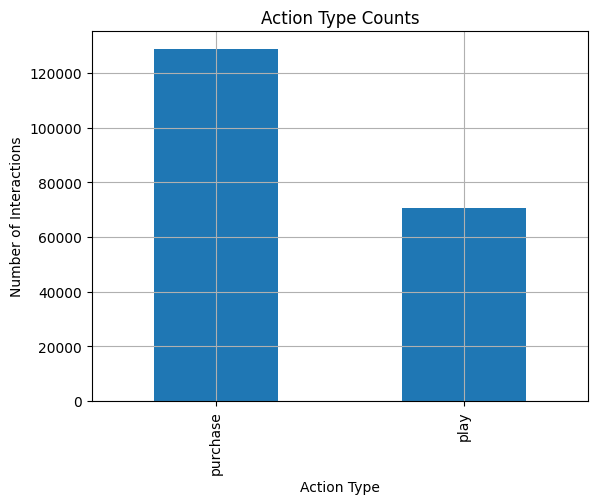

In [42]:
df_clean["action"].value_counts().plot(
    kind="bar",
    title="Action Type Counts",
    xlabel="Action Type",
    ylabel="Number of Interactions",
    grid=True
)

plt.show()

## 7. Game-level overview

Next, I check which games appear most often in the dataset.  
This gives a first idea about the most common games in the interaction records.

In [43]:
top_games_by_interactions = df_clean["game"].value_counts().head(15)
top_games_by_interactions

game
Dota 2                             9682
Team Fortress 2                    4646
Counter-Strike Global Offensive    2789
Unturned                           2632
Left 4 Dead 2                      1752
Counter-Strike Source              1693
Counter-Strike                     1424
Garry's Mod                        1397
The Elder Scrolls V Skyrim         1394
Warframe                           1271
Half-Life 2 Lost Coast             1158
Sid Meier's Civilization V         1150
Robocraft                          1096
Half-Life 2 Deathmatch             1021
Portal                             1005
Name: count, dtype: int64

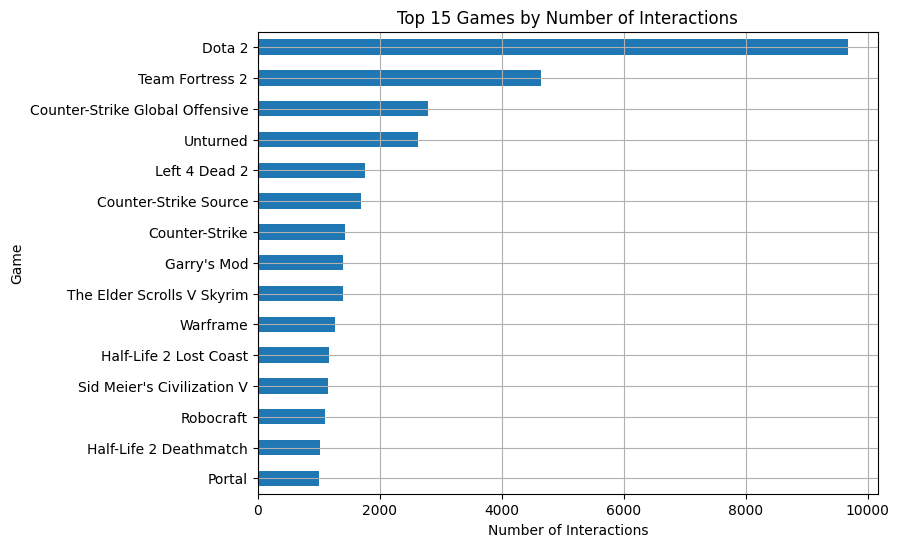

In [44]:
top_games_by_interactions.sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    title="Top 15 Games by Number of Interactions",
    xlabel="Number of Interactions",
    ylabel="Game",
    grid=True
)

plt.show()

## 8. Playtime analysis

For playtime analysis, I only use rows where the action is `play`.  
Purchase rows are not treated as gameplay hours.

In [45]:
play_df = df_clean[df_clean["action"] == "play"].copy()
play_df.head()

,user_id,game,action,hours
1,151603712,The Elder Scrolls V Skyrim,play,273.0
3,151603712,Fallout 4,play,87.0
5,151603712,Spore,play,14.9
7,151603712,Fallout New Vegas,play,12.1
9,151603712,Left 4 Dead 2,play,8.9


In [46]:
play_df["hours"].describe()

count    70489.000000
mean        48.878063
std        229.335236
min          0.100000
25%          1.000000
50%          4.500000
75%         19.100000
max      11754.000000
Name: hours, dtype: float64

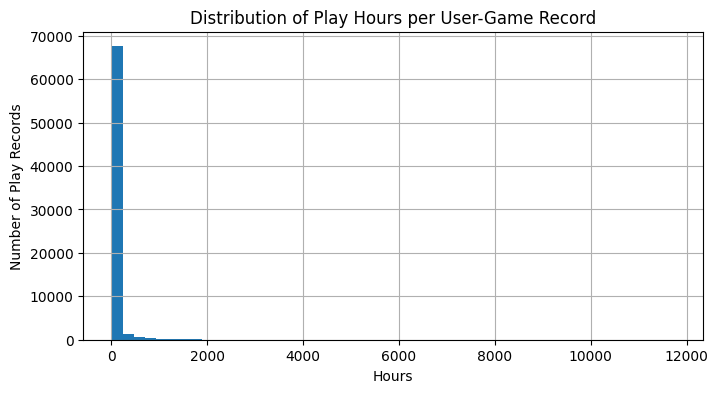

In [47]:
play_df["hours"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4),
    title="Distribution of Play Hours per User-Game Record",
    xlabel="Hours",
    ylabel="Number of Play Records",
    grid=True
)

plt.show()

The play hours distribution is expected to be right-skewed because some users spend very high amounts of time on a small number of games.
To make the distribution easier to read, I also look at a capped version.

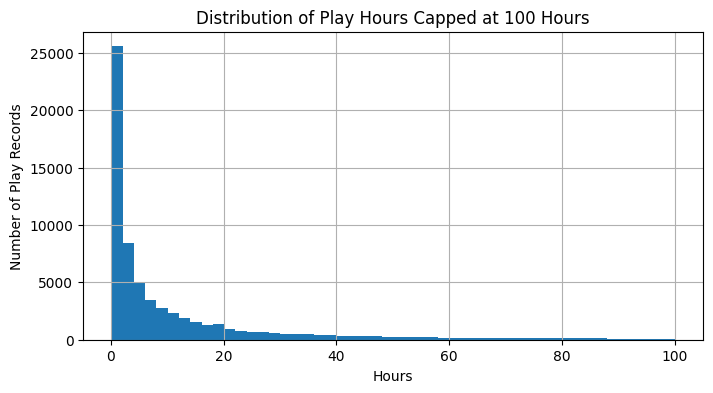

In [48]:
play_df[play_df["hours"] <= 100]["hours"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4),
    title="Distribution of Play Hours Capped at 100 Hours",
    xlabel="Hours",
    ylabel="Number of Play Records",
    grid=True
)

plt.show()

## 9. Top games by total playtime

Interaction count and playtime are not the same.  
A game may appear many times, but another game may have much higher total playtime.

In [49]:
top_games_by_hours = (
    play_df.groupby("game")["hours"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_games_by_hours

game
Dota 2                                         981684.6
Counter-Strike Global Offensive                322771.6
Team Fortress 2                                173673.3
Counter-Strike                                 134261.1
Sid Meier's Civilization V                      99821.3
Counter-Strike Source                           96075.5
The Elder Scrolls V Skyrim                      70889.3
Garry's Mod                                     49725.3
Call of Duty Modern Warfare 2 - Multiplayer     42009.9
Left 4 Dead 2                                   33596.7
Football Manager 2013                           32308.6
Football Manager 2012                           30845.8
Football Manager 2014                           30574.8
Terraria                                        29951.8
Warframe                                        27074.6
Name: hours, dtype: float64

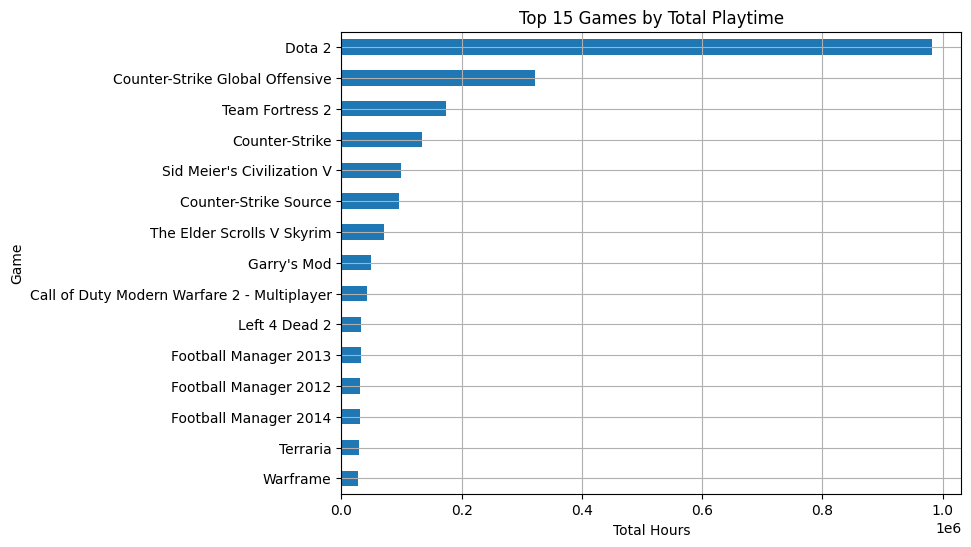

In [50]:
top_games_by_hours.sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    title="Top 15 Games by Total Playtime",
    xlabel="Total Hours",
    ylabel="Game",
    grid=True
)

plt.show()

## 10. User-level feature table

The raw data is interaction-level.  
For clustering and modeling, I need user-level features.  
These features are created by grouping the raw data by `user_id`.

In [51]:
user_features = create_user_features(df_clean)
user_features.head()

,user_id,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio
0,5250,225.5,8.351852,144.0,21,21,27,10.738095,0.777778
1,76767,1227.0,21.910714,365.0,36,36,56,34.083333,0.642857
2,86540,255.0,2.628866,113.0,82,82,97,3.109756,0.845361
3,103360,0.0,0.000000,0.0,10,10,10,0.000000,1.000000
4,144736,0.1,0.011111,0.1,8,8,9,0.012500,0.888889


In [52]:
user_features.shape

(12393, 9)

In [53]:
user_features.describe()

,user_id,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio
count,1.239300e+04,12393.000000,12393.000000,12393.000000,12393.000000,12393.000000,12393.000000,12393.000000,12393.000000
mean,1.611377e+08,278.009021,30.123010,176.163520,10.393287,10.393287,16.081094,55.471616,0.609983
std,8.001490e+07,760.270618,125.155644,504.764658,35.635890,35.635890,51.653103,241.296617,0.157643
min,5.250000e+03,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.500000
25%,9.706903e+07,1.300000,0.450000,1.200000,1.000000,1.000000,2.000000,0.833333,0.500000
50%,1.649396e+08,13.500000,3.200000,11.600000,2.000000,2.000000,3.000000,5.676923,0.500000
75%,2.209560e+08,155.600000,15.927586,107.000000,6.000000,6.000000,9.000000,27.500000,0.666667
max,3.099031e+08,11754.000000,5877.000000,11754.000000,1068.000000,1068.000000,1566.000000,11754.000000,1.000000


## 11. User behavior distributions

I now inspect the main user-level features that will be used later for segmentation.

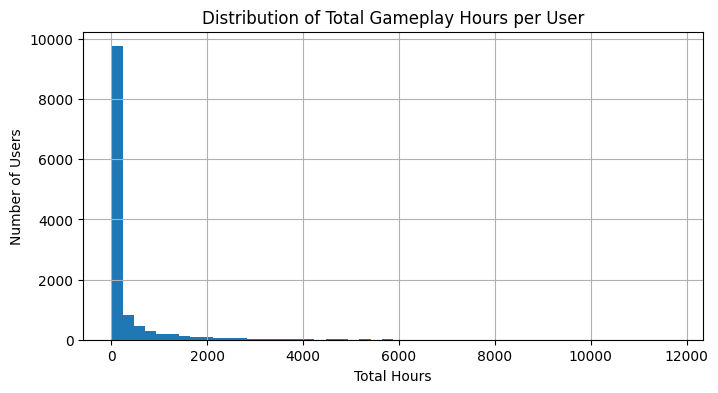

In [54]:
user_features["total_hours"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4),
    title="Distribution of Total Gameplay Hours per User",
    xlabel="Total Hours",
    ylabel="Number of Users",
    grid=True
)

plt.show()

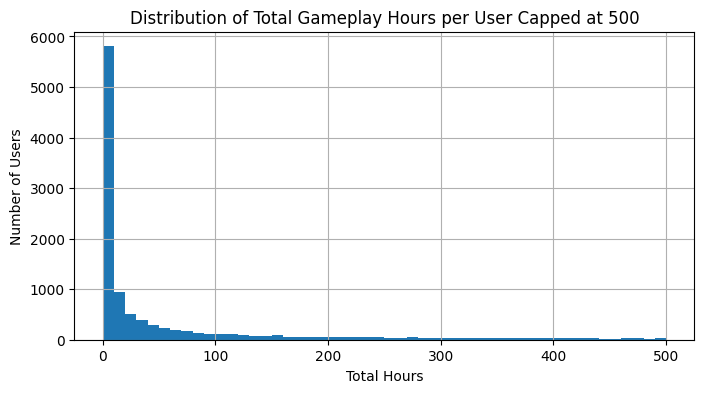

In [55]:
user_features[user_features["total_hours"] <= 500]["total_hours"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4),
    title="Distribution of Total Gameplay Hours per User Capped at 500",
    xlabel="Total Hours",
    ylabel="Number of Users",
    grid=True
)

plt.show()

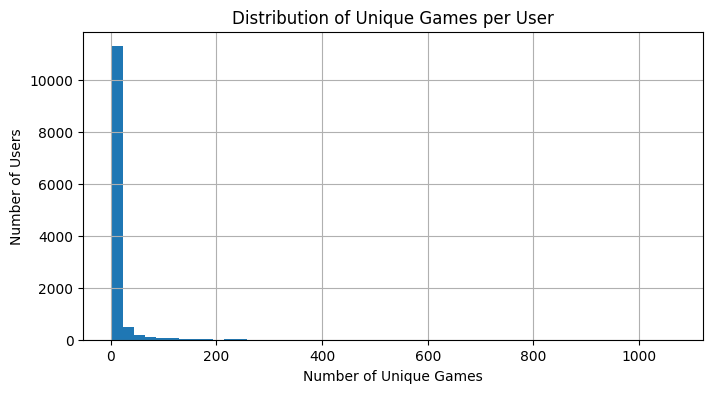

In [56]:
user_features["unique_games"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4),
    title="Distribution of Unique Games per User",
    xlabel="Number of Unique Games",
    ylabel="Number of Users",
    grid=True
)

plt.show()

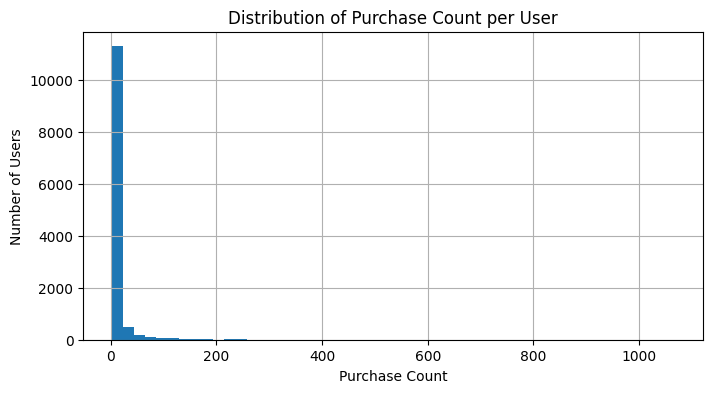

In [57]:
user_features["purchase_count"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4),
    title="Distribution of Purchase Count per User",
    xlabel="Purchase Count",
    ylabel="Number of Users",
    grid=True
)

plt.show()

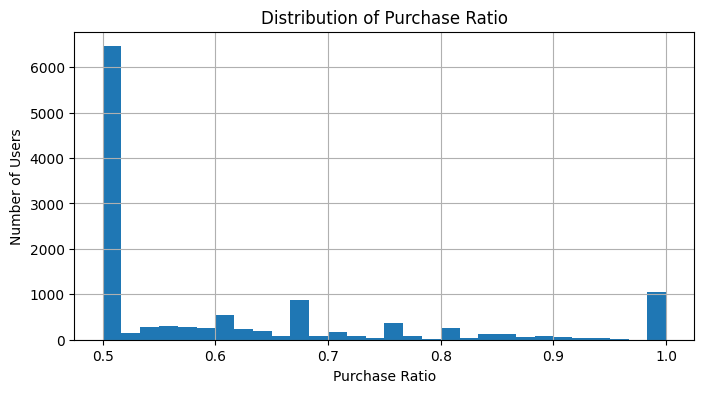

In [58]:
user_features["purchase_ratio"].plot(
    kind="hist",
    bins=30,
    figsize=(8, 4),
    title="Distribution of Purchase Ratio",
    xlabel="Purchase Ratio",
    ylabel="Number of Users",
    grid=True
)

plt.show()

## 12. Correlation between user-level features

Finally, I check correlations between the user-level behavioral features.  
This helps understand which features move together before clustering and modeling.

In [59]:
user_features.drop(columns=["user_id"]).corr()

,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio
total_hours,1.000000,0.458297,0.858703,0.466462,0.466462,0.501266,0.434740,-0.006872
avg_hours,0.458297,1.000000,0.663924,-0.032361,-0.032361,-0.031930,0.994729,-0.083513
max_hours,0.858703,0.663924,1.000000,0.194010,0.194010,0.208204,0.632395,-0.010622
unique_games,0.466462,-0.032361,0.194010,1.000000,1.000000,0.990425,-0.034720,0.101834
purchase_count,0.466462,-0.032361,0.194010,1.000000,1.000000,0.990425,-0.034720,0.101834
total_interactions,0.501266,-0.031930,0.208204,0.990425,0.990425,1.000000,-0.034012,0.071737
hours_per_game,0.434740,0.994729,0.632395,-0.034720,-0.034720,-0.034012,1.000000,-0.097638
purchase_ratio,-0.006872,-0.083513,-0.010622,0.101834,0.101834,0.071737,-0.097638,1.000000


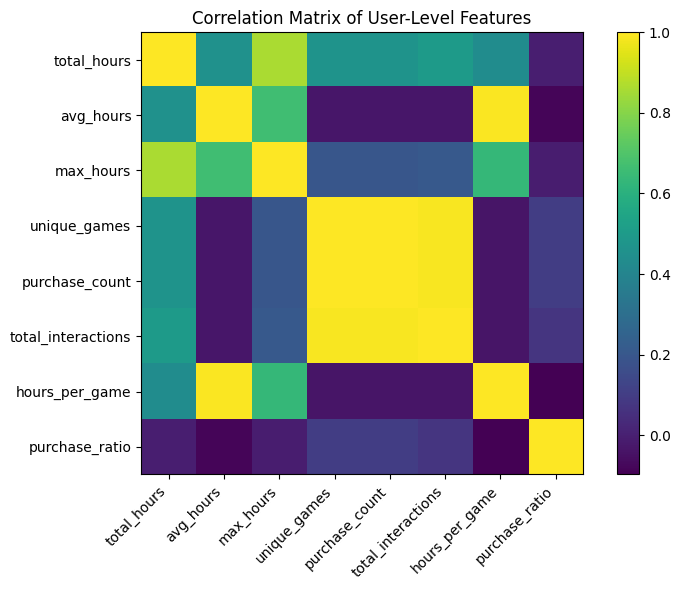

In [60]:
corr = user_features.drop(columns=["user_id"]).corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

fig.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix of User-Level Features")

plt.tight_layout()
plt.show()

## 13. Main observations from the initial EDA

At this stage, the main observations are:

- The dataset is interaction-level, so user-level feature engineering is needed.
- The data contains two action types: purchase and play.
- Purchase values should not be treated as gameplay hours.
- Playtime is highly skewed, with some users or games having very large values.
- The processed user-level table gives a better structure for clustering and modeling.

The next notebook will focus on feature engineering, scaling, K-Means clustering, and PCA visualization.